<center><span style="font-size:80px;"><b>DASK</b></span></center>

In [26]:
from IPython.display import Image, display

---

---

---

---

<center><span style="font-size:50px;"><b>INTRODUCTION</b></span></center>

Dask is an open source Python library for parallel and distributed computing. It was developed around 2015 to address a central limitation of the Python ecosystem: scaling computations beyond a single core or a single machine while keeping a familiar, Pythonic interface.

Dask is designed in three conceptual layers: 
- **high-level collections**
- **low-level parallel APIs**
- **core scheduler and execution subsystem**

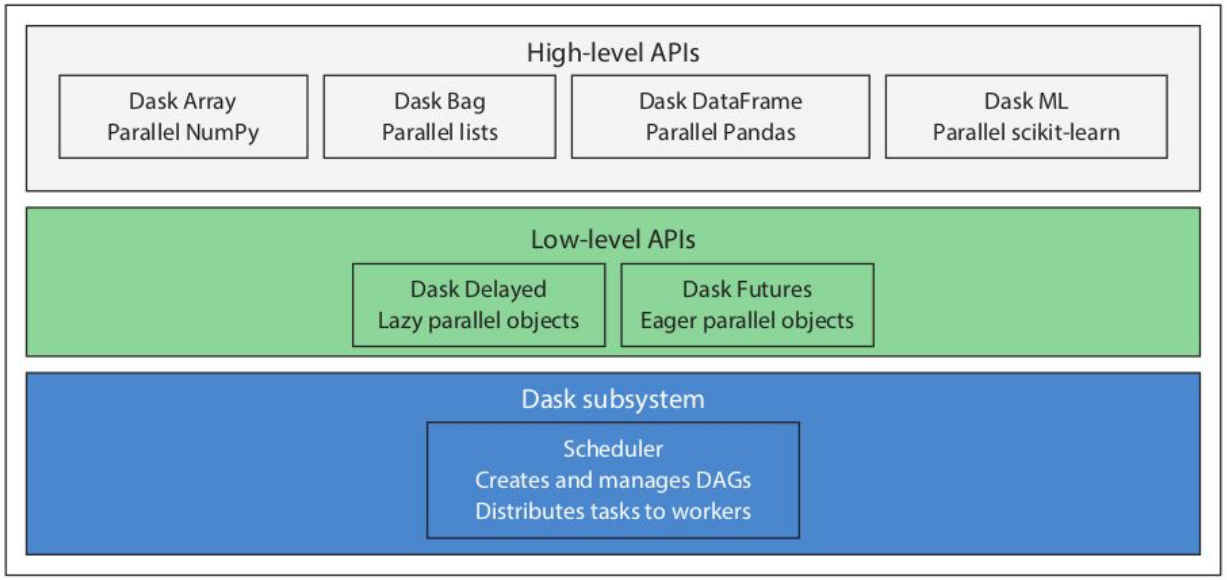

In [28]:
display(Image("./images/dask_conceptual_layers.png", width=600))

### HIGH-LEVEL APIs: Distributed Data Collections

At the highest level, Dask provides distributed data structures that mimic common Python and scientific computing tools. The idea is simple: **extend familiar objects so they can operate in parallel** and across multiple machines, without changing the programming model too much:
- *Dask DataFrame* is internally composed of multiple Pandas DataFrames, each representing a partition of the data.  
- *Dask Array* is composed of multiple NumPy arrays, each representing a chunk.  
- *Dask Bag* provides parallel processing for generic Python iterables.  
- *Dask-ML* extends scikit-learn for distributed machine learning workflows.

Each partition or chunk can be processed independently. These pieces may live on different machines in a cluster, or be processed sequentially on a single machine using multiple cores. **The user interacts with what looks like a single large object, but under the hood Dask manages many smaller pieces in parallel.**

---

### LOW-LEVEL APIs: Parallelizing Arbitrary Python Code

Below the high-level collections, Dask provides generic tools to parallelize almost any Python function. These APIs give fine-grained control over task execution and do not require using Dask DataFrame or Dask Array.

Two important execution models are supported:
- **Lazy execution** builds a task graph without running it immediately, through the command `delayed`. At this point nothing is executed. Dask records the operation in a task graph (a directed acyclic graph, or DAG). When you call `compute` Dask optimizes the task graph and then executes it in parallel over available threads, processes, or distributed workers.
- **Eager execution** starts computation immediately hrough the command `submit`, which immediately sends the task to the cluster. The returned object is a **future**, which acts as a promise of a result that will become available later. 

Note that speedup is not automatic: the code must be structured so that tasks can run independently and are large enough to justify scheduling overhead.

---

### CORE LEVEL: Scheduler and Resource Management

At its core, Dask is a task scheduler optimized for executing Python code as a directed acyclic graph of tasks. Every computation is translated into a DAG. The scheduler analyzes dependencies between tasks and determines which tasks can run in parallel.

Dask provides multiple schedulers:
* Single-threaded scheduler, mainly for debugging.
* Local threaded scheduler, which runs tasks in parallel threads on one machine.
* Local process scheduler, which uses multiple processes on one machine.
* Distributed scheduler, which can run tasks across multiple machines in a cluster. Despite its name, it can also be used locally to manage multiple worker processes. This is the one used when we deploy manually a cluster using `Client`

The distributed scheduler is the most powerful and flexible option. It separates responsibilities into a scheduler process and multiple worker processes, enabling scaling from a laptop to a large cluster.

Ususally the scheduler is automatically chosen by Dask, but you can choose it yourself using for example:
```python
(...).compute(scheduler="processes")
(...).compute(scheduler="single-threaded")
```
Dask can also integrate with external cluster resource managers such as SLURM, PBS, YARN, or Kubernetes. In these environments, Dask does not replace the cluster manager but uses it to request resources and launch workers dynamically.

Dask is particularly useful when:
- Data does not fit in memory (e.g. our dataset is bigger than our available RAM memory).
- Computations are slow and need parallel execution.
- You want to scale from a laptop to a cluster without changing much code.

Core Concepts:
* Task Graph: Dask builds a **task graph** representing computations lazily. The graph is executed only when `.compute()` is called.
* Scheduler: The **scheduler** is responsible for executing the task graph. 
* Workers: In distributed mode, **workers** execute tasks. Each worker runs in its own process and can be on the same machine or different machines.

Limitations of Dask:
- Overhead for very small computations.
- Not ideal for extremely complex custom dependency graphs.
- Some Pandas/NumPy features are not fully supported.

## SCHEDULER AND WORKERS

When you use Dask in distributed mode, your computation is managed by two main components: the **scheduler** and the **workers**.

The **scheduler** is the central coordinator of the cluster (and it is always only one). Its responsibilities include:
- Receiving the **task graph** generated by your computation.
- Determining the **order of execution** based on dependencies.
- Assigning tasks to workers.
- Tracking task states (waiting, running, finished, errored).
- Managing data movement between workers.

Importantly, the scheduler *does not perform heavy computations*. Its job is coordination and decision-making. It keeps track of where data lives and ensures that tasks are executed efficiently and in the correct order. You can think of the scheduler as the “brain” of the cluster.

The **workers** are the processes that actually perform the computations. Each worker:
- **Executes tasks** assigned by the scheduler.
- Stores intermediate results in memory.
- Communicates data to other workers when necessary.
- Reports status and results back to the scheduler.

Workers typically use multiple threads (or processes) internally, allowing them to execute multiple tasks in parallel. You can think of workers as the “hands” of the cluster — they do the real work.

#### STEPS

When you submit a computation:
1. Dask builds a task graph.
2. The scheduler analyzes the graph and determines which tasks are ready.
3. Tasks are assigned to workers.
4. Workers compute results and store them in memory.
5. If other tasks depend on those results, the scheduler schedules them accordingly.

#### WHAT ARE THEY

Technically, *scheduler* and *workers* are Python processes.

Each worker process can use multiple threads (default behavior). Each thread can execute one task at a time. So if a worker is configured with 4 threads, it can execute up to 4 tasks in parallel (subject to the GIL and task type).

On a laptop with 8 CPU cores, you might have:
- 1 scheduler process  
- 4 worker processes, each worker with 2 threads  

Total parallel task capacity: up to 8 concurrent tasks (depending on workload type).

## GENERAL GUIDELINES for Choosing the Number of Workers and Threads

The number of *workers* and *threads per worker* can be tuned depending on:
- Number of CPU cores
- Nature of the workload (CPU-bound vs I/O-bound)
- Memory per worker

1. **Numerical/Heavy workloads**: workload where tasks are mostly computations (NumPy, Pandas, etc.).
    Recommended setup:
    - 1 worker per CPU core or slightly fewer if running locally.
    - 1 thread per worker
    - **2 or more threads per worker** for tasks dominated by NumPy, Pandas, Scikit-learn, or Numba. These libraries release the Global Interpreter Lock (GIL), allowing true parallel execution across threads. Example: `--nworkers 1 --nthreads 4`

2. **I/O-bound workloads**: tasks that spend time in pure Python code, or waiting on disk/network I/O. Multiple threads per worker may be limited by the GIL, so heavy Python code can block other threads. Recommended setup: **Multiple worker processes**, each with **few threads**. Example: `--nworkers 4 --nthreads 1`.

3. **Memory considerations**: each worker holds data in memory. Launching too many workers may exceed available RAM. Consider the ratio *memory per worker*: total memory / number of workers.

## WORKFLOW
The workflow is given by:
- **Subdivide large datasets that won't fit into memory into smaller subsets (partitions)**
- **Design the entire data processing pipeline before execution and optimize it by breaking it into smaller tasks**
- **Schedule and distribute processing close to the data, minimizing data movement (data locality)**

# STARTING A CLUSTER

When working on a single machine, the simplest way to start using Dask Distributed is:

```python
from dask.distributed import Client
client = Client()
````

When you call `Client()` with no arguments, Dask automatically does several things for you:
* It creates a LocalCluster.
* It starts one scheduler process.
* It launches a set of worker processes (by default, one per logical CPU core).
* It connects the client to that cluster.
* It starts the dashboard at [http://localhost:8787](http://localhost:8787).

The `Client` is your main entry point to the distributed system, it represents the user whos asks tasks to the cluster. It is a lightweight Python object that connects to a scheduler, submits tasks and computations and retrieves results. It acts as a bridge between your Python session (for example, your notebook) and the scheduler.

#### LOCAL CLUSTER

`LocalCluster` is a helper class that creates a distributed cluster on a single machine. It starts one scheduler process and multiple worker processes on the same machine. You can explicitly configure it like this:

```python
from dask.distributed import Client, LocalCluster

cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=2
)

client = Client(cluster)
```

The options for LocalCluster are:
* `n_workers` controls how many worker processes are created.
* `threads_per_worker` controls how many threads each worker process uses.
* `memory_limit`: limit memory per worker
* `processes`: whether to use processes (True by default) or threads-only mode
* `dashboard_address`: customize dashboard location



#### SSH CLUSTER

LocalCluster runs everything on one machine. `SSHCluster` is different: it is used to start workers on multiple remote machines via SSH.

With SSHCluster, you provide a list of hostnames, and Dask:
* Connects to each machine via SSH: so we need SSH access to each machine
* Starts worker processes remotely: so we need Python and Dask installed on all machines
* Connects them to a central scheduler: so we need Network connectivity between them

```python
from dask.distributed import Client, SSHCluster

# Define your hosts (3 workers in this case)
hosts = [   
    "user@machine1.example.com",   
    "user@machine2.example.com",
    "user@machine3.example.com"
]

# Create an SSHCluster
cluster = SSHCluster(
    hosts,                                                   # By default, the scheduler will run on the first host listed
    connect_options={"known_hosts": None},                   # optional, disables strict host key checking
    worker_options={"nthreads": 2, "memory_limit": "4GB"},   # threads and memory per worker
    scheduler_options={"port": 8786}                         # optional scheduler port
)

client = Client(cluster)      # we create the client that connects to the cluster

print(client)                 # Check cluster status
```

It is good practice to **close a cluster** when you are done using it, especially if you explicitly created one. This frees up resources (CPU, memory) and shuts down the scheduler and worker processes cleanly.

If you just created a client without expliciting the Cluster, when your Python session ends the cluster usually shuts down automatically. However, you can still call `client.close()` to cleanly terminate the cluster early:

```python
client.close()
```
If you created a cluster explicitly with LocalCluster or SSHCluster you should close both the client and the cluster when done:

```python
client.close()
cluster.close()
```

---

---

---

---

<center><span style="font-size:50px;"><b>DELAYED AND SUBMIT</b></span></center>

### DELAYED

In order for Dask to leverage the processing units assigned to the cluster, we need to construct the Directed Acyclic Graph (DAG) corresponding to the execution of the code we want to deploy on the cluster. Subsequently, we allow the scheduler to dispatch the tasks to the workers.

This is accomplished in Dask by marking a function as `delayed`:
```python
from dask import delayed

result = delayed(your_function)(<your_function_arguments>)
```

The `delayed` method in Dask accepts two main arguments:
- The first argument is the function to be executed in parallel.
- The subsequent arguments are the arguments upon which the original function will operate.

Note: the delayed tool can also be used as a decorator:
```python
@dask.delayed
def func():
    #.....
```

In [9]:
# EXAMPLE FUNCTION TO PARALLELIZE
def slow_square(x):
    time.sleep(1)
    return x * x

In [8]:
%%time

results = [ slow_square(i) for i in range(3) ]
total = sum(results)

CPU times: user 807 μs, sys: 728 μs, total: 1.54 ms
Wall time: 3 s


As expected, in our example, the computation time is 3 seconds (1s sleep for each call).

Let's try using parallel computation.

In [2]:
from dask import delayed
import time

# Build lazy computation
results = [ delayed(slow_square)(i) for i in range(3) ]

total = delayed(sum)(results)

# Nothing happens yet!
total

Delayed('sum-77608eee-57e6-4309-ac67-84b14c116be2')

At this stage, as is typical with lazy operations, the results are not yet stored in `total`. At this stage, `total` simply represents the "plan" of the code execution, created by the Directed Acyclic Graph (DAG) task scheduler.

To visualize the plan of execution, we can utilize the `visualize()` method (note that the `graphviz` Python package is required for this). This visualization represents the task graph **before** any optimization is applied. We can also request Dask to provide the DAG **after** optimization by using the `optimize_graph=True` option.

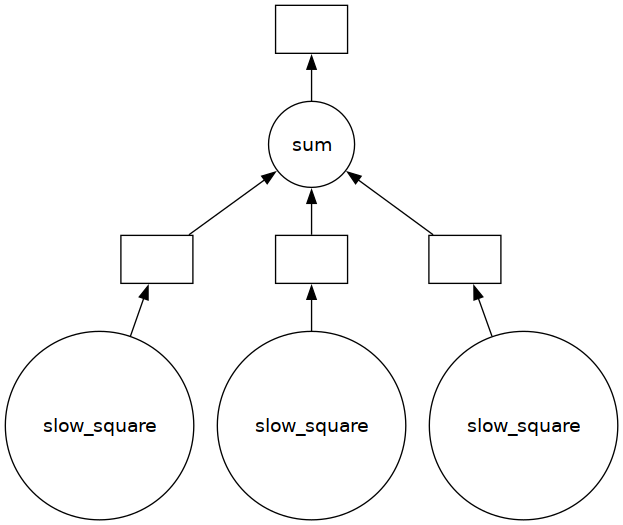

In [4]:
total.visualize(optimize_graph=True)

Alternatively, Dask also offers a high-level task visualization tool `.dask` that can be accessed by clicking on it from within a Jupyter notebook.

In [5]:
total.dask

HighLevelGraph with 4 layers.
<dask.highlevelgraph.HighLevelGraph object at 0x7f9de97f4080>
 0. slow_square-9925369f-df34-48e0-b3ee-abacbc3b1f55
 1. slow_square-e0fb91d8-6896-419b-bc51-3084567a9d50
 2. slow_square-8bf3cc10-41aa-4ae0-9f43-9983bf2ee595
 3. sum-77608eee-57e6-4309-ac67-84b14c116be2

To actually execute the job, we need to instruct Dask to trigger the execution by requesting the results of the lazy operation with the `compute()` method. Under the hood, Dask will send the computational graph to the scheduler and dispatch the tasks to the workers.

It's important to note that `compute()` is a blocking operation, meaning that the program will wait for the results to be computed before proceeding.

In [7]:
%%time

# Execute the graph
total.compute()

CPU times: user 1.04 ms, sys: 2.86 ms, total: 3.89 ms
Wall time: 1 s


5

Now it took only 1 second!

#### EXAMPLE

In [ ]:
from time import sleep

def increment(x):       # dummy function incrementing the input value by 1
    sleep(0.01)
    return x + 1

def decrement(x):       # dummy function decrementing the input value by 1
    sleep(0.01)
    return x - 1

def add(x, y):          # dummy function summing two input values
    sleep(0.01)
    return x + y

In [ ]:
%%time

# make the function behave as lazy with delayed
#
# result = delayed(your_function)(<your_function_arguments>)
x = delayed(increment)(1)
y = delayed(decrement)(2)
z = delayed(add)(x, y)

In [ ]:
z.compute() 

Below we can see the Status Page (in the dashboard) of the previous computation.\
On the left, the <span style="color:green;">green</span> and dark-<span style="color:blue;">blue</span> rectangles represent the $10$ $ms$ sleep time for the increment and decrement fucntions.\
In the center, the <span style="color:red;">red</span> part is the $0.66$ $ms$ data transfer time of the results towards the add function.\
On the right, in <span style="color:blue;">blue</span>, we see the $10$ $ms$ computation time of the add function.

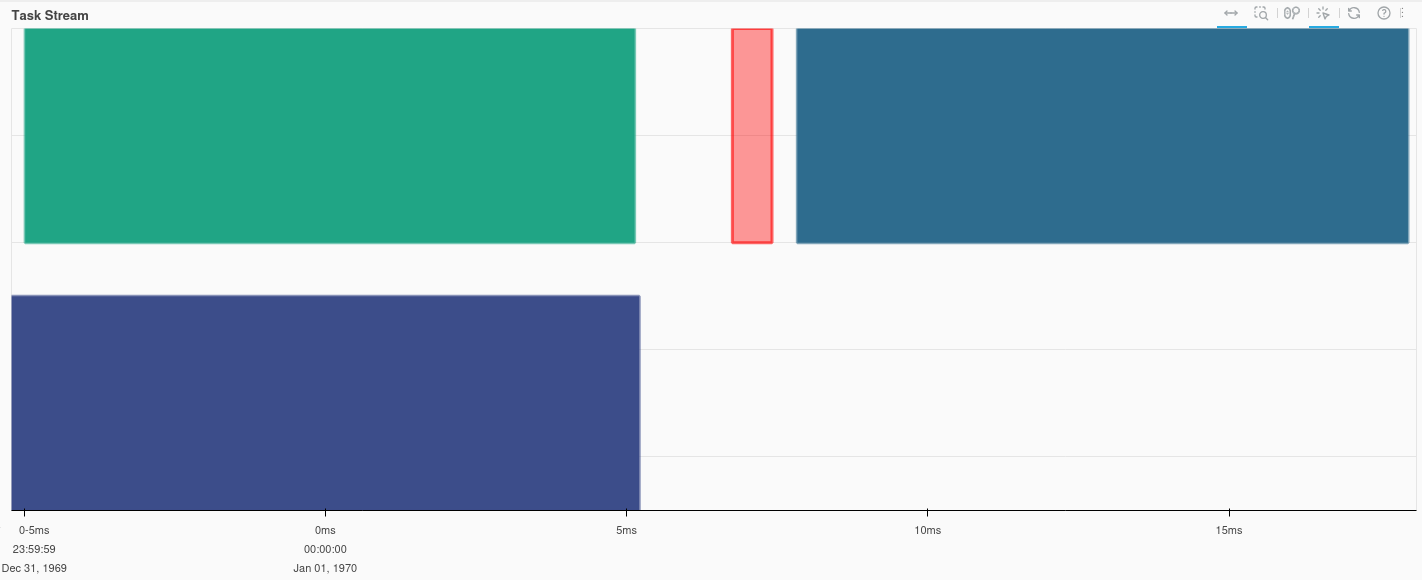

In [30]:
display(Image("./images/dask_simple_example.png", width=800))

### FUTURES

Dask provides multiple ways to execute computations in parallel. We have seen *delayed*, which is good for building a *lazy task graph* and then computing it all at once. The eager operation alternative to *delayed* in Dask is `submit`. Using `submit` instructs Dask to **immediately submit our task to the cluster and begin executing it** on the available computing resources. 

A *Dask Future* is a Python object representing a computation that may be running asynchronously on the cluster:
- When you submit a function to a Dask cluster with `client.submit()`, you immediately get a **future object**.
- This future acts as a placeholder for the result of that computation.
- The actual task runs on a worker process, possibly in parallel with other tasks.
- You can later retrieve the result with `.result()` or wait for it with `.done()`. The result of the computation will remain on the worker nodes of our cluster and will not be sent back to our client until we explicitly request it.
- Useful when you want to work with tasks individually, rather than computing a large static graph.

Think of a future as a **promise that the computation will eventually produce a value**.

Use futures when you want:
1. **Immediate execution** rather than building a task graph:
   - *delayed* builds a graph and computes it all at once with *compute().
   - *submit* starts the task right away.
2. **Dynamic or interactive workflows**:
   - Submit tasks as data arrives.
   - Process results immediately when a task finishes.
3. **Fine-grained control** over individual tasks:
   - Check if a task is done (`future.done()`).
   - Cancel tasks (`future.cancel()`).
   - Chain computations dynamically using `client.submit()` on results of other futures.

Example:

```python
def slow_square(x):
    time.sleep(2)
    return x ** 2

# Submit tasks asynchronously
future1 = client.submit(slow_square, 10)              # return a "promise" of getting the actual result
future2 = client.submit(slow_square, 20)

# (................)
# Do other work in Python while Dask runs these tasks
# (................)

# Retrieve results
result1 = future1.result()
result2 = future2.result()

print(result1, result2)
````

So `client.submit()` schedules a single function on the cluster and returns a future. You can submit as many futures as you want; Dask will schedule them across available workers. Futures can also be passed as arguments to other futures for **dynamic chaining**:

```python
future3 = client.submit(lambda x, y: x + y, future1, future2)
print(future3.result())  # waits for future1 and future2 automatically
```

In summary:

| Feature           | dask.delayed                   | dask future                                         |
| ----------------- | ------------------------------ | --------------------------------------------------- |
| Execution         | Lazy, builds a task graph      | Immediate / asynchronous                            |
| Result access     | `compute()` on the whole graph | `.result()` on each future                          |
| Dynamic workflows | Less convenient                | Easy to submit tasks as results arrive              |
| Interactive use   | Limited                        | Ideal for interactive Python sessions and streaming |


### RESULT AND GATHER

The method `fut.result()` is called on a single Future object. It blocks until that specific task finishes and then returns its result.\
The method `client.gather( fut )` is called on the Client and is typically used when you have many futures. It takes a list (or nested structure) of futures and returns their results in the same structure, so it waits for all of them.

In [11]:
from dask.distributed import Client, LocalCluster

cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=2,
    dashboard_address=":8686"        # see the dashboard at http://localhost:8686
)

client = Client(cluster)

In [12]:
# return a "promise" of getting the actual result
future = client.submit(slow_square, 2)
future

<Future: pending, key: slow_square-b53cae8cfe2acf2f76c217d9003e2b88>

In [16]:
print( future.result() )
print( client.gather(future) )

4
4


### MAP

The concept behind this approach allows us to *map* the instruction we want to execute to each element of a dataset, effectively submitting the same operation across the entire dataset. The command `client.map` operates **asynchronously**, meaning that the cluster computes the results without blocking our local Python code for task completion.\
It is basically a *submit* applied to an iterable.

In [17]:
data = [0, 1, 2, 3, 4]

# submit the increment function on ALL elements of the list using a `map` approach (each element is independent from the others)
future_results = client.map(slow_square, data)
 
future_results    # with this we visualize the status of the futures

[<Future: pending, key: slow_square-c5a901d1cf4c8d33cc8cd4a0479623a0>,
 <Future: pending, key: slow_square-06ac837c6465faacf7fb6ae47848f3b0>,
 <Future: pending, key: slow_square-a6f6e8e2b998c9bd4bb37e7a318382c9>,
 <Future: pending, key: slow_square-dc7733141fdc5144d9799fab314d56b6>,
 <Future: pending, key: slow_square-c153035a613daef03e54462c0e0aefca>]

In [18]:
# retrieve the data from the cluster
new_data = client.gather(future_results)
print(new_data)

[0, 1, 4, 9, 16]


### WAIT

However, **if** we need to wait for the result of a `submit` computation to be ready — for instance, if we require it as an input for other computations — we can use the `wait` method. This method blocks the execution of new code and waits for the computation of the future.

In [19]:
from dask.distributed import wait

# start the computation
new_future = client.map(slow_square, new_data)

# block this python process 
# and wait for the remote task to be completed
wait(new_future)

DoneAndNotDoneFutures(done={<Future: finished, type: int, key: slow_square-23fdb3bc2d736c6c54d40e38a5c01194>, <Future: finished, type: int, key: slow_square-06ac837c6465faacf7fb6ae47848f3b0>, <Future: finished, type: int, key: slow_square-c153035a613daef03e54462c0e0aefca>, <Future: finished, type: int, key: slow_square-ce223a74f3d96d406dcf9f487f03bf42>, <Future: finished, type: int, key: slow_square-c5a901d1cf4c8d33cc8cd4a0479623a0>}, not_done=set())

In [20]:
new_future    # This time the computation is already finished

[<Future: finished, type: int, key: slow_square-c5a901d1cf4c8d33cc8cd4a0479623a0>,
 <Future: finished, type: int, key: slow_square-06ac837c6465faacf7fb6ae47848f3b0>,
 <Future: finished, type: int, key: slow_square-c153035a613daef03e54462c0e0aefca>,
 <Future: finished, type: int, key: slow_square-23fdb3bc2d736c6c54d40e38a5c01194>,
 <Future: finished, type: int, key: slow_square-ce223a74f3d96d406dcf9f487f03bf42>]

### EXAMPLE

In [21]:
import random
import time

# input data
data = [1, 2, 3, 4, 5, 6, 7, 8]

# 1. increment function
def add_rand(x):
    return x+random.random()

# 2. multiplication function
def mult_ten(x):
    return x*10

# placeholder for the updated array
results = []

# 3. for each element
#  - add a random value
#  - multiply by ten
#  - append the new data in a list
for x in data:
    y =  delayed(add_rand)(x) 
    z =  delayed(mult_ten)(y) 
    results.append(z)
    
# 4. sum all elements of the list
total = delayed(sum)(results) 

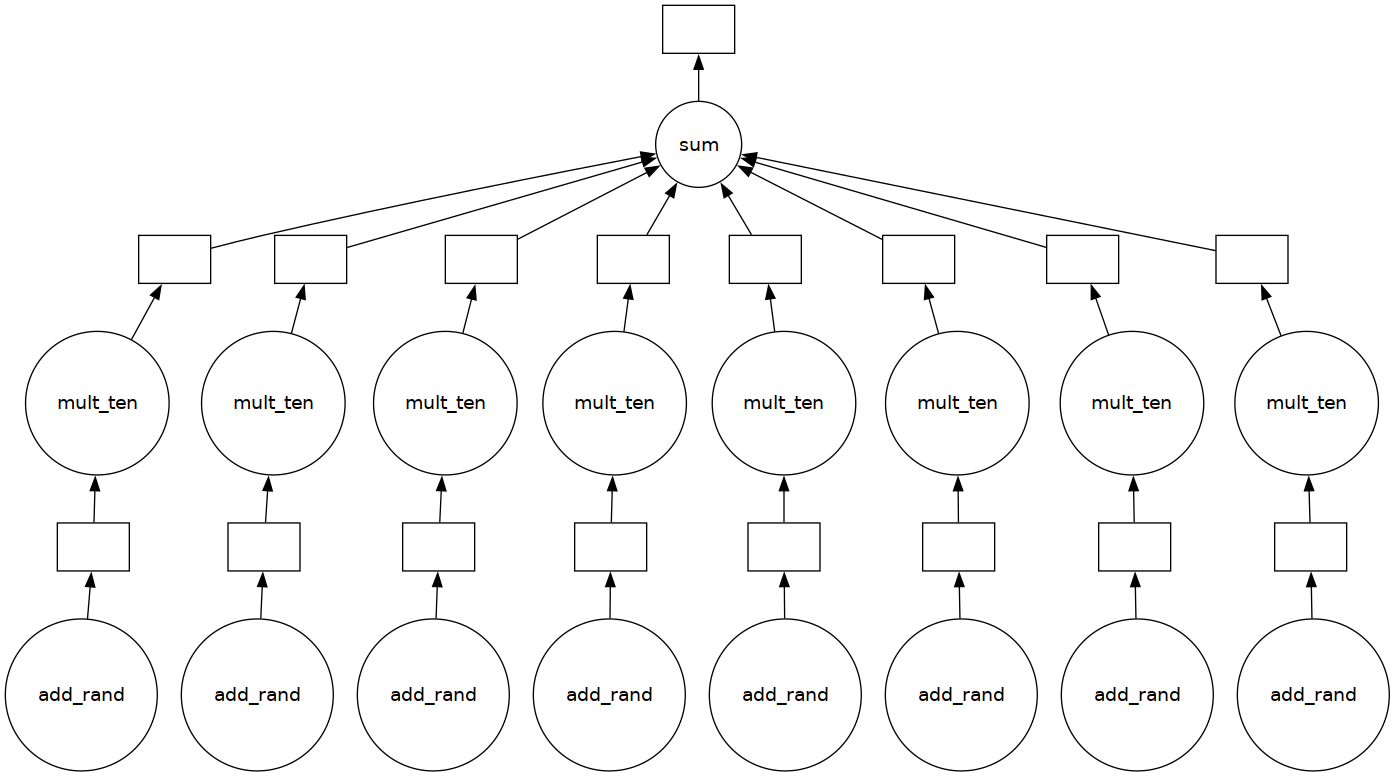

In [22]:
total.visualize(optimize_graph=True)

In [23]:
%%time

# compute the result and time it
result = total.compute()

CPU times: user 14 ms, sys: 117 μs, total: 14.1 ms
Wall time: 23.6 ms


In [24]:
print("result: ",result)

result:  401.52072189865765


### PROBLEM WITH PURE FUNCTIONS

When using the distributed scheduler, Dask tries to avoid recomputing the same task multiple times. This behavior is based on the idea of pure functions.\
A **pure function** is a function that always returns the same output when given the same input and has no side effects. Because of this property, Dask can safely reuse previously computed results. Internally, the scheduler builds a key for each task using the function and its arguments. If two tasks have the same key, Dask assumes they are identical and may reuse the result instead of executing the function again.

This behavior can cause problems when the function is not actually pure. Consider a function that generates a random number:

```python
def generate_random(x):
    return random.random()
```

Even if the input `x` is the same, the function produces different outputs each time it is executed. However, Dask does not know this. If we write:

```python
futures = client.map(generate_random, [1]*10000)
results = client.gather(futures)
```

Dask sees 10000 tasks that all call the same function with the same argument `1`. Since it assumes the function is pure, it may compute the task once and reuse the same result for all 10000 tasks. As a consequence, you could end up with 10000 identical numbers instead of 10000 independent random values.

To avoid this behavior, we can tell Dask that the function is impure. An **impure function** is a function that may return different outputs even when called with the same inputs. **Random number generators, functions that read files, or functions that depend on the current time are typical examples.**

We can disable the purity assumption by passing `pure=False`:

```python
future = client.submit(generate_random, 1, pure=False)
# or
futures = client.map(generate_random, [1]*10000, pure=False)
```

However, marking tasks as impure reduces some of Dask’s optimization capabilities. When tasks are assumed to be pure, the scheduler can reuse results, avoid duplicate work, and cache computations. When tasks are impure, the scheduler must execute each task independently, which can increase scheduling overhead and reduce efficiency in large task graphs.

### LIMITATIONS OF DASK

At first glance, we expect parallel code to be faster than single-threaded code. However, this is not always true. In some cases, a Dask implementation can be slower than the equivalent plain Python version. \
The main reason is **overhead**. Overhead refers to extra work that is not part of your actual computation, but is required to manage and coordinate it. When you use plain Python in a single thread, the interpreter simply executes your loop and your function calls directly.

When you use Dask, several additional things happen:
- A task graph is created.
- The scheduler analyzes and traverses this graph.
- Tasks are serialized and sent to worker processes.
- (etc)

All of this coordination takes time. That time is overhead. It is necessary for distributed execution, but it does not directly contribute to your actual computation.

For example, each `delayed` task has a fixed scheduling cost, and can incur hundreds of microseconds of overhead. This means that if you create thousands of tiny tasks, the accumulated overhead can dominate the total runtime. In that case, the Dask version can easily become slower than a simple Python loop.

> Parallelism only helps when the useful work per task is large enough to compensate for the scheduling cost.

Parallelization is most beneficial when:
- Each task is computationally heavy.
- Data is large.
- The workload can be cleanly divided into independent chunks.
- Computation time per task is much larger than scheduling overhead.

Therefore, it is always important to benchmark parallel code against a single-threaded implementation. Parallelization is a powerful tool, but it is not automatically faster in every situation.

---

---

---

---

<center><span style="font-size:50px;"><b>DASK BAG</b></span></center>

Bags serve as **parallelized collections of objects, similar to Python's built-in list**, capable of holding any Python objects, whether they're custom classes or built-in types. 

Due to this versatility, Dask bags are commonly employed to parallelize simple computations on **unstructured or semi-structured data**, such as text data, log files, JSON records, or user-defined Python objects. They facilitate MapReduce-like approaches for loading, inspecting, filtering, and processing arbitrary datasets, whether structured or unstructured.

```python
import dask.bag as db
```

These functions are used to create a Dask Bag from data sources:
* `from_sequence()`: creates a Bag from a Python iterable
* `read_text()`, `read_json()`, `from_delayed()`: other ways to create Bags from files or delayed computations

These functions operate on *each individual element* (so element-wise) of the Bag:
* `map(func)`: apply a function to each element
* `filter(func)`: keep only elements that satisfy a condition
* `starmap(func)`: apply a function to argument tuples (useful after `groupby`)

These functions operate on *whole partitions* at once:
* `map_partitions(func)`: apply a function to an entire partition
* `flatten()`: flatten nested sequences within each partition

These are *reductions or combiners* that summarize or reorganize data:
* `groupby(key)`: group elements by a key
* `foldby(key, binop, init)`: reduction by key (combines map+reduce efficiently)
* `fold(func)` or `reduction(func)`: perform parallel reductions
* `distinct()`: remove duplicates
* `count()`: count elements
* `frequencies()`: count occurrences of values

Operations to select or inspect elements:
* `take(n)`: retrieve the first `n` elements
* `topk(n, key)`: retrieve the top `n` elements by a key function


Since a Bag is inherently a `delayed` object, there's no need to explicitly specify that the functions applied to the dataset are further delayed. Dask handles the delayed execution transparently, allowing for efficient processing of large datasets.
By the fact that they are lazy, we know that they construct a task graph (and do not execute immediately), so we can use `visualize()`. Computation starts only when a terminal operation such as `.compute()` is called. It accomplishes these tasks in parallel using Python iterators, resembling a parallel version of *itertools*.

After performing preprocessing or transformations with Dask Bag, it is often convenient to convert the data into more structured formats such as Dask DataFrame or Dask Array, which are optimized for tabular or numerical computations.

#### CREATE A BAG

We can create a `Bag` from various data sources, including Python sequences, files, and cloud storage services like Amazon AWS S3, among others. For a comprehensive overview on accessing remote data from Distributed File Systems, S3, and other sources, please refer to the official documentation [here](https://docs.dask.org/en/stable/how-to/connect-to-remote-data.html).

A Dask Bag can be created from several sources. In all cases, the bag is divided into partitions. Each partition contains multiple elements and can be processed independently by workers. The number of partitions (`npartitions`) determines the level of parallelism and should typically scale with the size of the dataset and the available computing resources.


```python
# EXAMPLES:
b = db.from_sequence(range(1000), npartitions=10)         # from a Python sequence
b = db.read_text("logs/*.txt")                            # from a collection of files (for example text or JSON files)
```

It is also possible to construct a bag from `delayed` computations. This allows data to be generated or loaded through distributed tasks and then manipulated using the Bag API.

```python
@delayed
def load_data():
    return [1, 2, 3, 4]

b = db.from_delayed([load_data()])
```

#### USING A BAG

Since Dask uses lazy evaluation, operations on a Bag do not execute immediately. To obtain the actual data in memory, we must trigger computation. To convert a Dask Bag into a Python list, we use `.compute()`. This executes the task graph, gathers the results from all partitions, and returns a standard Python list containing all elements of the bag.

```python
b = db.from_sequence([1, 2, 3, 4], npartitions=2)

result = b.compute()
print(result)
```

Output:

```
[1, 2, 3, 4]
```

If the bag contains a very large dataset (i.e. when it it useful), converting it entirely to a Python list may require a large amount of memory, since the whole result must fit in the local process. In such cases it is often better to perform reductions or aggregations (e.g. `sum`, `count`, `frequencies`) directly within Dask rather than collecting all elements locally.

In [8]:
import dask.bag as db

b = db.from_sequence([1, 2, 3, 4, 4, 5]).frequencies()
b.compute()

[(1, 1), (2, 1), (3, 1), (4, 2), (5, 1)]

In [11]:
import dask.bag as db

b = db.from_sequence([1, 2, 3, 4, 5])                 # create a Dask Bag from a Python iterable
b = db.from_sequence([1,2,2,3,3,3]).distinct()        # remove duplicate elements
b = db.from_sequence([1,2,2,3,3,3]).frequencies()    # count occurrences of each value, and returns couples (element, frequency)

b = db.from_sequence([1, 2, 3, 4, 5])      
b.take(3)                                             # retrieve the first 3 elements from the bag (from the first partition)
b.map(lambda x: x**2)                                 # apply a function to each element (square each value)
b.filter(lambda x: x % 2 == 0)                        # keep only elements satisfying a condition (even numbers)
b.map_partitions(lambda part: [sum(part)])            # apply a function to an entire partition (sum elements inside each partition)
db.from_sequence([[1,2], [3,4], [5]]) .flatten()      # flatten nested sequences into a single sequence
db.from_sequence(["apple","ant","banana","boat"]).groupby(lambda x: x[0])  # group elements by a key (here by first letter)
b.fold(lambda x, y: x + y)                            # parallel reduction combining elements (sum all elements)
b.count()                                             # count total number of elements

/home/benedetto/anaconda3/lib/python3.12/site-packages/dask/bag/core.py:2519: UserWarning: Insufficient elements for `take`. 3 elements requested, only 1 elements available. Try passing larger `npartitions` to `take`.
  warnings.warn(


dask.bag<dictitems, npartitions=1>

In [15]:
b = db.from_sequence([1,2,2,3,3,3]).frequencies()    # count occurrences of each value, and returns couples (element, frequency)

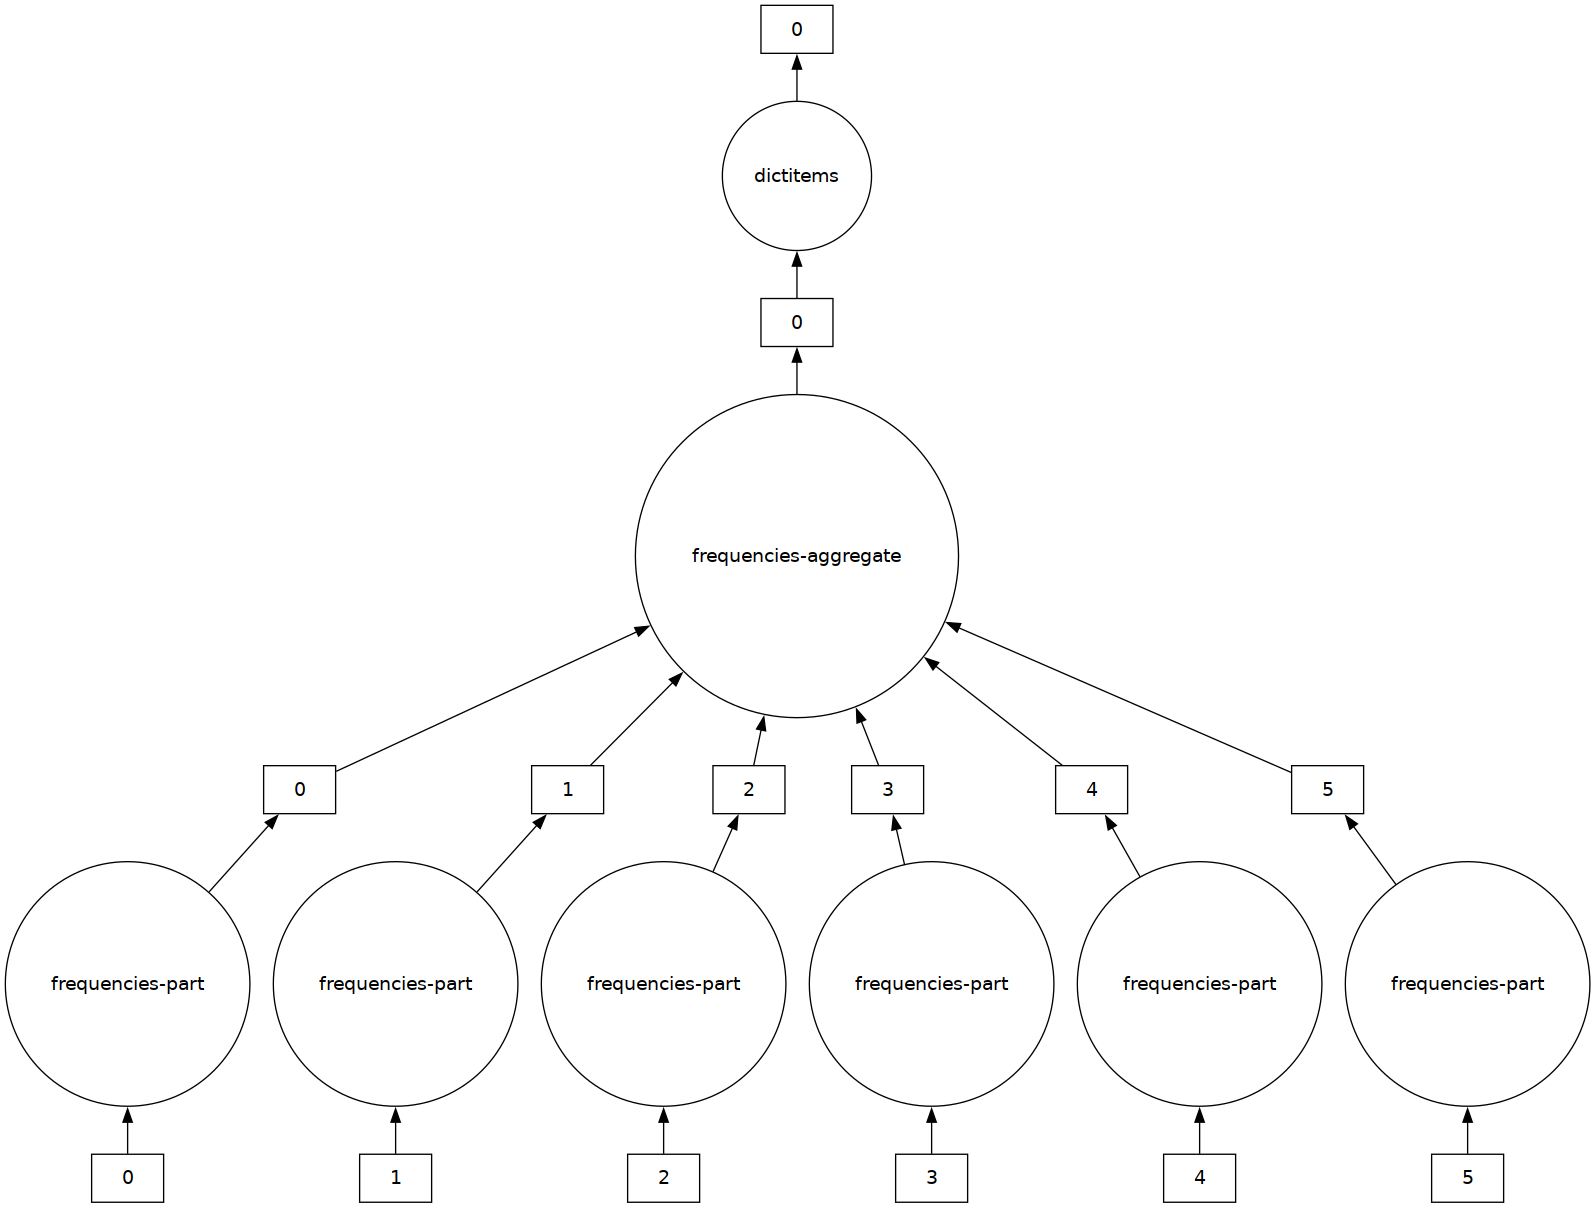

In [17]:
b.visualize()

In [18]:
b.compute()

[(1, 1), (2, 2), (3, 3)]

#### FOLD-BY

While *groupby* moves all the data across the network to group them (a slow operation called a shuffle), *foldby* performs a partial reduction on each partition before sending the data to other workers (more efficiency). It is equivalent to a combination of two operations: `groupby` and `reduce`. It is the Dask equivalent of the Map-Reduce paradigm.

When using `foldby`, you need to provide:
1. A **key function to group elements** (similar to `groupby`).
2. Either:
    - A **binary operator** (function that takes 2 elements and returns 1 of the same type) that performs reduction within each group.
    - Or a **combine binary operator** that can combine the results of two `reduce` calls on different parts of your dataset.

In Dask, a `foldby` call like this:
```python
dask_bag.foldby(key, binop, init)
```

The 3 Main Arguments are:
- *key* (Function): Determines how to group the elements. It receives an element $x$ and returns the group key (e.g., lambda x: x % 2).
- *binop* (Binary Operation): This is the aggregation function. It receives two arguments: the current accumulator and the new element (e.g., *add* function). 
- *init* (Initial Value or Function): The starting point of the accumulator for each group. It can be a fixed value (like 0) or a function that generates the initial value.

The reduction operation must be associative and is executed in parallel within each partition of the dataset. The intermediate results are then combined using the `combine` binary operator.

In [24]:
b = db.from_sequence(list(range(10)))

# first row divides the numbers in two groups: even and odd. It returns two tuples: (0,[0,2,4,6,8]) and (1,[1,3,5,7,9])
# second row separates the elements in the tuples, and find the sum of the numbers in each group 
b.groupby(lambda x: x % 2)\
 .starmap(lambda k, v: (k, sum(v)))\
 .compute()

[(0, 20), (1, 25)]

In [26]:
# WHICH IS ALMOST EQUIVALENT TO:


#   write down a **binary filter function** to select only even or odd numbers
#   write down a **reduce-like operation** to sum all elements
is_even = lambda x: x % 2 == 0 
add     = lambda x, y: x + y
b.foldby(key=is_even, 
         binop=add, 
         initial=0).compute()

[(True, 20), (False, 25)]

### FROM BAG TO STRUCTURED DATA

Dask Bags are commonly used as an initial stage for data ingestion and preprocessing. In this stage the goal is usually to read the raw data, parse it, filter unwanted elements, and perform basic transformations. After this preliminary processing, it is often preferable to convert the data into a more structured format, such as a Dask DataFrame or a Dask Array. 

Dask provides several methods to export or convert the content of a Bag:
- `to_textfiles`: write the elements of the bag into multiple text files, typically one file per partition
- `to_avro`: write the bag into Avro files
- `to_delayed`: convert each partition of the bag into a delayed object, allowing integration with custom Dask workflows
- `to_dataframe`: convert the bag into a Dask DataFrame

A typical workflow when using Dask Bags follows the Extract–Transform–Load (ETL) pattern:
1. **Extract**: raw data is read from the original source (files, object storage, databases, logs, etc.)
2. **Transform**: the raw records are cleaned and processed using operations such as `map`, `filter`, `groupby`, or `fold`.
3. **Load**: the processed data is converted into a structured representation (for example a Dask DataFrame with `to_dataframe`) or written to a storage system for further analysis.

If the bag contains nested or irregular structures, it is usually necessary to first flatten or normalize the records so that each element corresponds to a consistent row-like structure. Once the data is in this form, the `to_dataframe()` method can be used to create a Dask DataFrame.

---

---

---

---

# 2. DASK ARRAY

Dask Array mimics NumPy but works on chunked arrays.

In [7]:
import dask.array as da
import numpy as np

# Create large random array (chunked)
x = da.random.random((10000, 10000), chunks=(2000, 2000))

x

dask.array<random_sample, shape=(10000, 10000), dtype=float64, chunksize=(2000, 2000), chunktype=numpy.ndarray>

In [8]:
# Lazy computation
mean = x.mean()
mean

dask.array<mean_agg-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>

In [9]:
# Compute result
mean.compute()

0.5000309183545403

---

---

---

---

# 3. DASK DATAFRAME

Dask DataFrame parallelizes Pandas operations.

In [10]:
import dask.dataframe as dd
import pandas as pd

# Create sample Pandas DataFrame
pdf = pd.DataFrame({
    "A": range(1000000),
    "B": range(1000000)
})

# Convert to Dask DataFrame
ddf = dd.from_pandas(pdf, npartitions=4)

ddf

,A,B
npartitions=4,,
0,int64,int64
250000,...,...
500000,...,...
750000,...,...
999999,...,...


In [11]:
# Lazy operation
result = ddf["A"].mean()
result

<dask_expr.expr.Scalar: expr=df['A'].mean(), dtype=float64>

In [12]:
result.compute()

499999.5

---

---

---

---

---

---

---

---

# 5. USING THE DISTRIBUTED SCHEDULER

You can start a local distributed cluster with:

In [15]:
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 15.43 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42895,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 16
Started: Just now,Total memory: 15.43 GiB
Comm: tcp://127.0.0.1:46657,Total threads: 4
Dashboard: http://127.0.0.1:41363/status,Memory: 3.86 GiB
Nanny: tcp://127.0.0.1:39539,


---

---

---

---

---

---

---

---

# 6. DASHBOARD INTERPRETATION

When working with **Dask**, the **dashboard** is an essential tool to monitor and understand what's happening in your computations across the cluster. It is particularly helpful for diagnosing performance issues and seeing how tasks are scheduled and executed.

If you are using **Dask** on a single machine (which is common during development), the dashboard runs automatically when you create a `Client` object:

```python
from dask.distributed import Client
client = Client()
````

---

## 6.1 STATUS PAGE

### STATUS PAGE: The Central Plot

The **Status page** is the first page you will often explore, and the **central plot** is key to understanding task execution:
* Each **line** in the plot corresponds to a **single thread/core** in your cluster.
* The **rectangles** along the line represent **individual tasks** being executed over time.
* Color coding groups tasks by type of operation. The same tasks will have the same colour every time it is computed
* **White spaces** indicate **idle time**, when a worker was not doing any task. This may happen due to:
  * Lack of tasks ready to execute
  * Scheduling delays
* **Red regions** indicate **communication**, i.e., the time spent transferring data between workers. Too much red could indicate network bottlenecks.

You can interact with the plot using the zoom tools (e.g., mouse wheel) to inspect individual tasks more closely.

#### TASK DURATION
When zoomed in:
* Each rectangle has a duration that shows how long the task took.
* Example: A task combining `arcsine` computation and generating random data might take **690 milliseconds** (see image below).
* Complex compositions of multiple operations (like creating random data, computing a cosine, and adding results) are broken down into colored segments corresponding to each operation.

This visual breakdown helps you identify which parts of a computation are taking the most time and whether idle times or data transfers are affecting performance.

### WORKER ACTIVITY
* **Solid colored blocks** show active computation. A high number of solid blocks mean your cluster is being efficiently utilized.
* **Gaps (white)** show inactivity—sometimes unavoidable due to task scheduling.
* **Red transparent areas** show data being transferred between workers. Example: Transferring results of a task to another worker. If communication dominates, you may need to rethink your computation strategy or upgrade network resources.

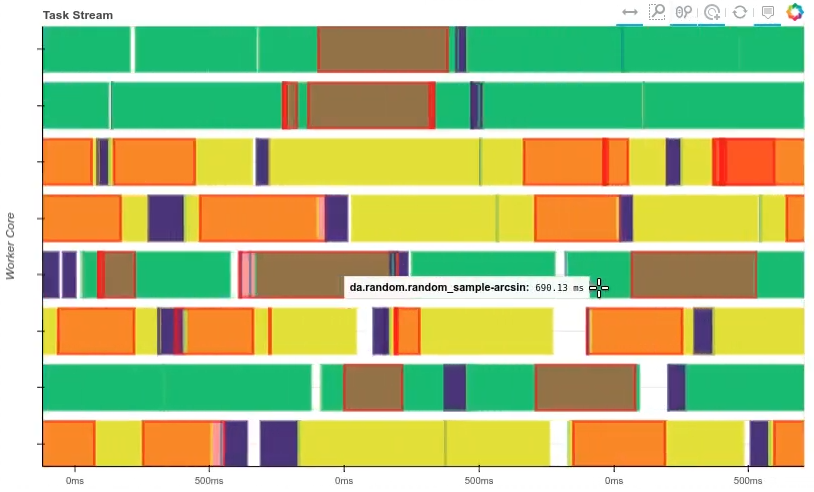

In [4]:
display(Image("./images/dask_dashboard_1.png", width=800))

### STATUS PAGE: Progress Bars

Next, let's examine the progress bars on the Dask dashboard, which give a more high-level view of how each type of task is progressing.

- Each progress bar corresponds to a **specific type of task** and uses the same color coding as the central task stream plot (the one from before). For example, `add` tasks appear in purple, just as in the task stream above.
- Progress moves **from left (not done) to right (completed)**, giving an intuitive sense of how far along each task type is.

A single progress bar is composed of **several segments**, each representing a different task state:
1. **Gray segment** (far right of the proceding colored bar)  
   - These are tasks that are **ready to run** but are not currently executing.  
   - They would start running if additional cores became available.
2. **Solid colored segment**  
   - These tasks have been **completed and are currently stored in memory (RAM)**.  
   - They are ready to be used by other computations but occupy memory.
3. **Transparent segment** (bigger component of the bar in the image below, the component in the left of the bar)  
   - These are tasks that have been **completed and released from memory**.  
   - This indicates that memory is being freed efficiently as computation progresses.

An ideal situation is when most progress bars **move steadily to the right**, showing that tasks are completing and memory is being released efficiently.  

- A small gray window is normal, indicating tasks waiting to run.  
- A small solid colored window indicates tasks temporarily occupying memory.  
- Large areas of any of the two cases just mentioned could signal **memory pressure** or **underutilized cores**, which might require tuning the computation or increasing resources.

So by observing these progress bars, you can quickly see how task execution and memory usage evolve during your computation, helping you identify bottlenecks or inefficiencies.

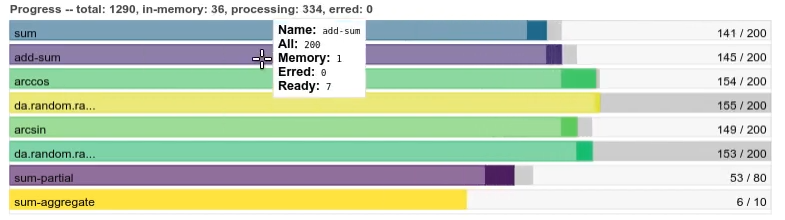

In [7]:
display(Image("./images/dask_progress_bars.png", width=800))

### STATUS PAGE: Monitoring Memory and Task Backlog

Another key aspect of the Dask dashboard is **memory usage per worker** and the **task backlog**, which help you understand both resource utilization and workload distribution.

#### MEMORY USAGE
At the top of the dashboard, there is a memory plot where **each line represents one worker**. This shows **how much RAM each worker is using** at any given time. In the image below (left plot), a worker is using **238 MB of RAM**. The total memory usage** of the cluster is displayed at the top, summing all workers (2.17GB in our example image).

**Color changes in the memory bars indicate approaching memory limits**. Bars may turn orange as a warning that memory usage is high. This helps identify potential memory bottlenecks before they cause task failures.

### TASK BACKLOG
The task backlog is visualized in the task stream plot as a segment for each worker. **Each segment represents tasks queued and ready to run** on that worker.

Ideally, the tasks are evenly distributed across all workers. If some workers have longer backlogs while others have very few tasks, it can indicate load imbalance.

Toward the end of a computation, some backlogs may **turn red** (like in the image below), signaling that a worker does not have enough tasks to keep all threads busy. This is normal as the computation winds down but is important for understanding thread utilization efficiency.

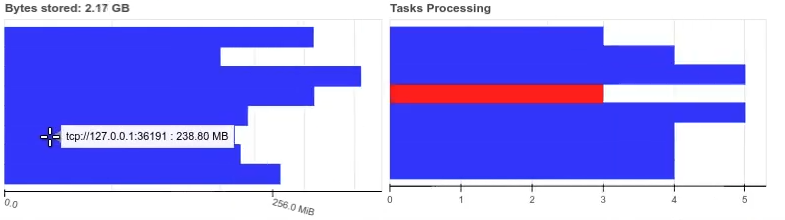

In [9]:
display(Image("./images/dask_ram_tasks.png", width=800))

---

## 6.2 PROFILE PAGE

The Status page gives you a coarse-grained view of your computation: each rectangle represents an entire task. However, it does not tell you what is happening *inside* those tasks — which functions are running, and which lines of code are consuming most of the time.

For that, you use the **Profile page**, which provides a much more detailed view of your code execution.

Unlike the Status page, this view **does not update automatically**. After running a new computation, you need to press the **Update** button to refresh the profiling data.

The Profile page is composed of two main parts:
1. A **time series plot** at the bottom  
2. A **flame graph** at the top  

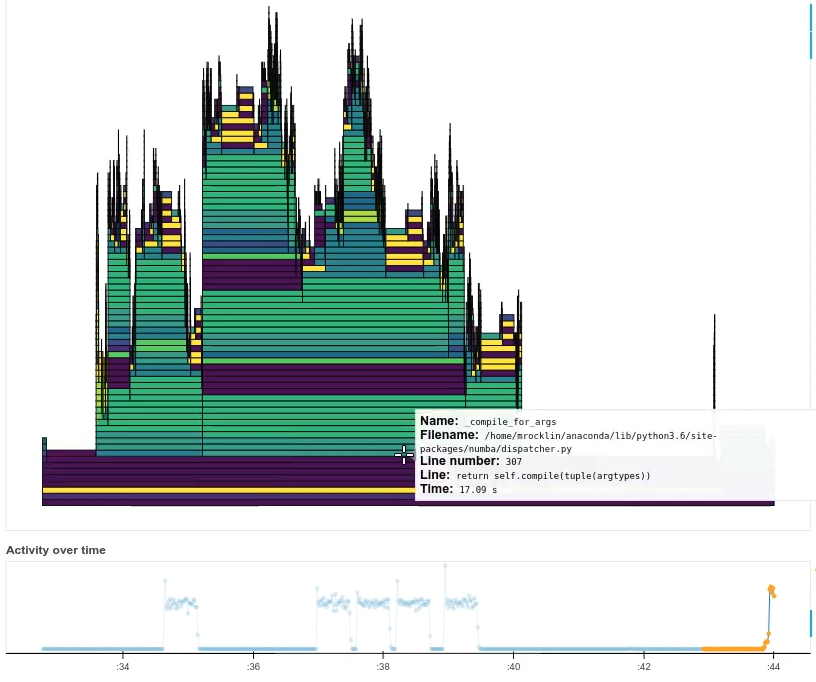

In [11]:
display(Image("./images/dask_dashboard_profile.png", width=1000))

### PROFILE PAGE: Time Series (Bottom Panel)
The time series shows **activity over time**.  

If you run a computation multiple times, you will see separate blocks of activity (like in the image above), possibly separated by gaps. This allows you to:
- Select a specific time window (highlighted in orange in the image above)
- Focus on a single run of your computation
- Compare different executions


### PROFILE PAGE: The Flame Graph (Top Panel)
The flame graph is the central tool for detailed profiling.

**Each horizontal bar represents a function**. The width of the bar represents the **total time spent inside that function**, aggregated across all workers. Important principles for reading the flame graph:
- If one bar is stacked above another, it means the upper function was called *inside* the lower one.
- The horizontal size indicates how much cumulative time was spent there.
- The bottom-most bar represents the "entry point" for that portion of computation.

This structure lets you trace the **call hierarchy** of your computation.

When analyzing a flame graph, you might observe that:
- A particular function dominates the width of the graph → this is your primary performance bottleneck.
- That function internally calls other functions, visible as stacked bars above it.
- A large portion of time might be spent inside library code (e.g., NumPy, file readers, serialization routines).

In many data-processing workloads (for example when reading data from disk), a large fraction of the time can be spent in file parsing, low-level numerical routines or just-in-time (JIT) compilation. For example, sometimes you may see a large amount of time spent inside compiled numerical code (for example when using libraries that rely on JIT compilation).

In these cases:
- The *first execution may be slow* because compilation happens.
- Subsequent executions can be significantly faster, since the compiled code is reused.

By comparing two runs in the Profile page, you can visually confirm this effect: the first run shows large blocks related to compilation, while later runs show much smaller and simpler stacks. This is a very useful diagnostic tool when evaluating performance improvements.

**The flame graph is interactive**:
- Clicking on a rectangle makes it the new "base" of the graph.
- The visualization will zoom into that function’s internal calls.

This allows you to understand performance at a very fine-grained level, down to individual function calls. You can always press Reset to return to the full view.

#### How Profiling Works Internally

At regular intervals (e.g., every few milliseconds), each worker checks what function each thread is currently executing. Over time, this produces a statistical estimate of where computation time is being spent.

---

## 6.3 SYSTEM PAGE

The **System page** gives you insight into what is happening at the *process and machine level*, rather than at the task or function level. While the Status and Profile pages focus on computation, the System page helps you monitor the **health and resource usage of the scheduler and workers**.

This is especially useful when diagnosing performance issues that may not be caused by your code directly, but by system-level constraints.

#### FIRST PLOT
This plot shows the **CPU usage of the scheduler process** (and sometimes workers, depending on configuration).

You will usually see a low baseline when idle and short spikes when a computation starts, as the scheduler builds and assigns tasks. After that, it should return to a stable level. Sustained high CPU usage may indicate heavy scheduling overhead or too many small tasks.


#### SECOND PLOT
This plot shows the **memory usage of the scheduler process** over time.

Memory should remain relatively stable. A steady increase may indicate accumulating metadata or large task graphs. Sudden jumps typically correspond to launching large computations.


#### THIRD PLOT
This plot shows the **network bandwidth usage per machine**, i.e., how much data is being transferred between workers.

You may see spikes during shuffles or data redistribution. High bandwidth is normal during communication-heavy phases, but if it stays very high or dominates runtime, you may be facing a communication bottleneck.


#### FOURTH PLOT
This plot shows how many **file descriptors** (open files, sockets, connections) the process is using.

A stable value is normal. A continuously increasing number may indicate resource leaks (e.g., too many open connections or files not being closed properly), which can eventually cause failures.

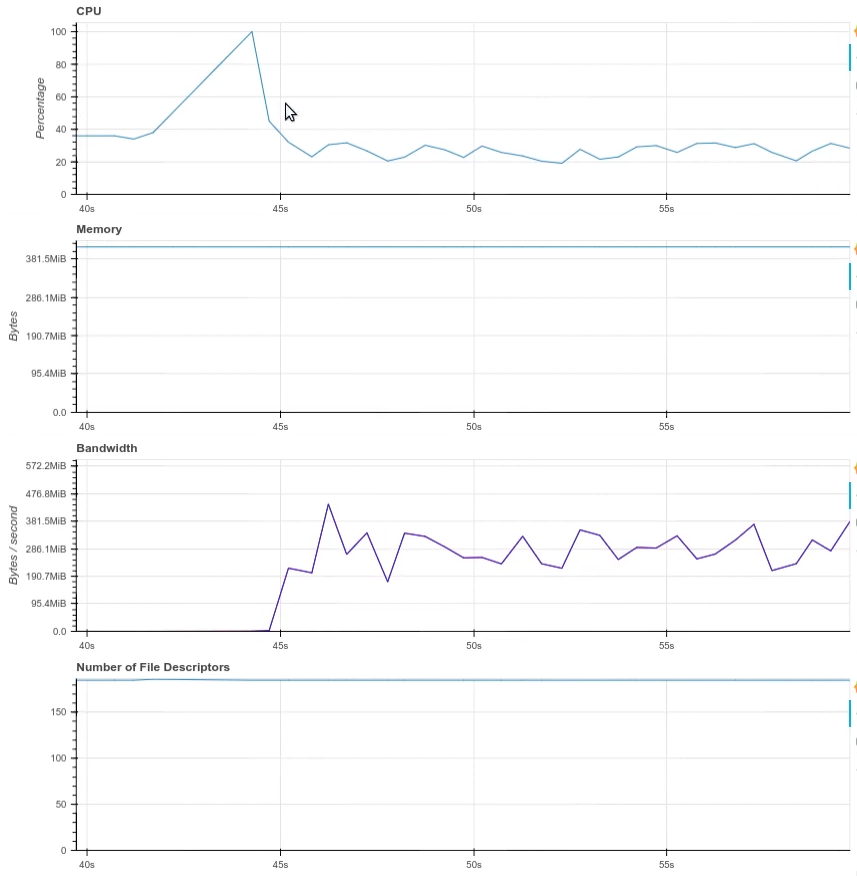

In [13]:
display(Image("./images/dask_system.png", width=700))

---

## 6.4 WORKERS PAGE

The Workers page provides a detailed view of each individual worker in your cluster. If you are running locally, all workers may be on the same machine, but in a distributed cluster this page becomes much more informative.

For each worker, you can see (image below):
- CPU usage
- Memory usage
- Other resource-related metrics

At the top, there is a **live resource usage plot** showing how these values evolve over time.

If one worker looks unusual (e.g., much higher memory usage or lower CPU activity than others), you can *select that worker*. When selected, the page filters to show detailed information only for that worker.

The Workers page is particularly useful when debugging **cluster imbalance problems**, ensuring that all workers are being used efficiently and that no single worker becomes a bottleneck.

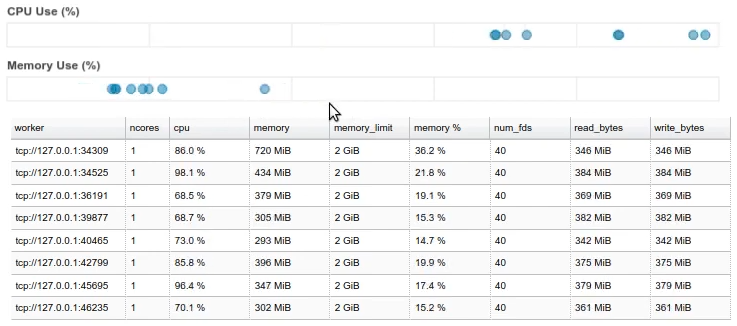

In [14]:
display(Image("./images/dask_workers_page.png", width=700))

---

## 6.5 INFO PAGE

The Info page provides a more detailed and mostly **static view** (does not update automatically) of what is happening inside the scheduler and workers.  

One of the most useful sections contains the **logs**:
- Logs for each worker  
- Logs for the scheduler  

These are particularly helpful when debugging errors, crashes, or unexpected behavior. If something fails silently in your computation, the logs are often the first place to look.

The Info page can also show:
- What each worker is currently working on  
- The exact **task key** being executed  
- The **call stack**, meaning the specific function and code path currently running  

This allows you to see, at a very precise moment, which function a worker thread is executing (for example, a NumPy routine or a user-defined function).

You can also inspect individual tasks in detail. For a given task, you may see:
- How much memory it is using  
- Its dependencies (which tasks must finish before it runs)  
- Which tasks depend on it  
- Its current state in the scheduler  

This information gives a very deep understanding of how the scheduler is managing that task.

The Info page is more of an **advanced debugging tool**.  

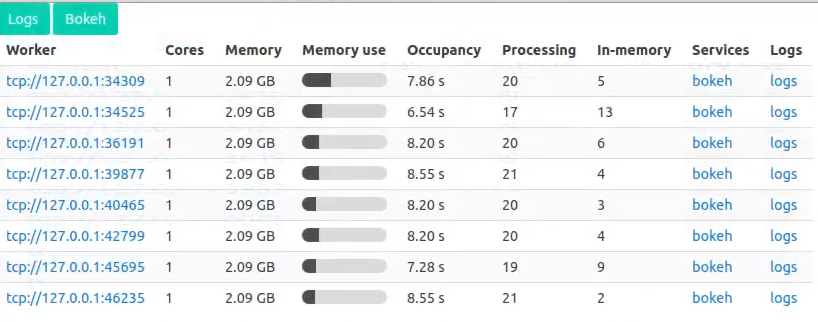

In [18]:
display(Image("./images/dask_info_page.png", width=600))

---

## 6.6 GRAPH PAGE

The Graph page shows the full **task graph** managed by the scheduler. This is a visual representation of your computation as a directed graph:
- Each **node** represents a task.
- Each **edge** represents a dependency between tasks.
- If one task depends on another, there will be a directed connection between them.

This view helps you understand the **structure of your computation**, not just its execution over time.

When you run a computation, the graph updates live. You can observe:
- New tasks appearing in the graph.
- Tasks changing color as they move through different states.
- Dependencies being resolved as upstream tasks complete.

Nodes change color depending on their state. For example:
- *Green* → tasks that are currently running or ready to run.
- *Blue* → tasks that have completed and whose results are in memory.
- *Red* → tasks whose results are stored in memory (RAM).
- *Black* → tasks that have errored.

While it may not be necessary for simple workflows, it becomes very valuable when working with large or complex task graphs, where understanding dependencies is key to optimizing performance.

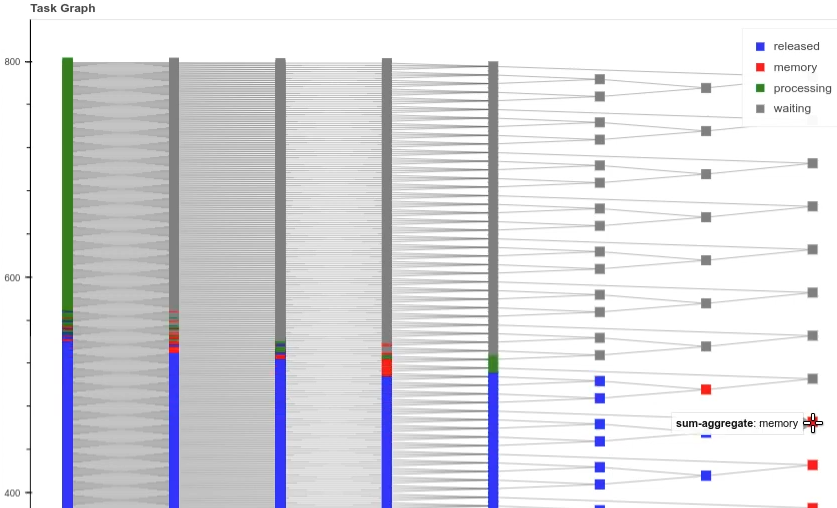

In [20]:
display(Image("./images/dask_graph_page.png", width=800))

- **Status** → task-level execution
- **Profile** → function-level execution
- **System** → machine-level resource usage
- **Info** → advanced debugging tool